In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# 將專案 root 加入 python path（讓 src/ 可以 import）
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added:", project_root)
print("✓ Imports ready")

Project root added: C:\Users\USER\Desktop\2026_japan
✓ Imports ready


In [2]:
from src.geo.grid_to_latlng import *

anchors = [
        {"x": 24, "y": 151, "lat": 43.06918333153887, "lng": 141.35147072116592},  # 札幌站 
        {"x": 24, "y": 148, "lat": 43.07940372979633, "lng": 141.34225589803765},  # 北海道大學
        {"x": 26, "y": 153, "lat": 43.05798589528942, "lng": 141.35402112326315},  # 狸小路商店街
        {"x": 52, "y": 81, "lat": 43.1982317547878, "lng": 140.99403634015297},  # 小樽站
        {"x": 50, "y": 41, "lat": 43.188064114901195, "lng": 140.79455411455163},  # 余市站
        {"x": 182, "y": 186, "lat": 43.85360951281324, "lng": 141.52348814480132},  # 増毛町文化センター
]

mapper = GridLatLngMapper(anchors)

In [3]:
import pandas as pd
from src.parks_choose import *
from src.parks_create import *
from src.parks_routing import *

START_DATE = '2019-09-15'

south = 42.9
north = 43.9
west = 140.7
east = 141.6

df_pred = pd.read_parquet("../data/predictions/convlstm_df_pred.parquet")

df_parks, df_with_a, df_prob = create_poi_parking(df_pred,south,west,north,east,mapper,START_DATE) 


In [4]:
df_prob.head()

,d,t,park_id,demand,pressure,p_avail,park_x,park_y,capacity,is_city,urban_score
0,1,0,node/10095286778,0.076275,0.000693,0.991771,23.862832,147.013421,110,1,0.932311
1,1,0,node/10188151756,1.501682,0.088334,0.000139,36.004512,136.971182,17,1,0.392041
2,1,0,node/10673369415,0.035760,0.001987,0.989950,21.511308,151.410173,18,1,1.547945
3,1,0,node/10674905656,0.047414,0.001185,0.991120,21.142992,151.374945,40,1,0.911731
4,1,0,node/11134318196,0.450856,0.001952,0.990004,21.383037,157.735259,231,1,0.715780


In [5]:
import numpy as np
import pandas as pd

def prepare_sim_inputs(df_prob: pd.DataFrame):
    """
        把 df_prob 轉成：
        - steps: (d,t) 的時間步索引
        - parks_meta: 每個 park 的靜態資訊
        - demand_mat: shape = (n_steps, n_parks) 的 demand 矩陣
    """
    required = {"d", "t", "park_id", "demand", "capacity", "is_city"}
    missing = required - set(df_prob.columns)
    if missing:
        raise ValueError(f"df_prob 缺少欄位: {missing}")

    df = df_prob.copy()

    df["d"] = df["d"].astype(int)
    df["t"] = df["t"].astype(int)
    df["demand"] = df["demand"].astype(float)
    df["capacity"] = df["capacity"].astype(int)
    df["is_city"] = df["is_city"].astype(int)

    # 時間步
    steps = (df[["d", "t"]].drop_duplicates().sort_values(["d", "t"]).reset_index(drop=True))

    # 停車場 metadata（確保每個 park_id 唯一）
    meta_cols = ["park_id", "capacity", "is_city"]
    parks_meta = (df[meta_cols].drop_duplicates(subset=["park_id"]).set_index("park_id").sort_index())

    # demand 矩陣：index=(d,t), columns=park_id
    demand_pivot = (df.pivot_table(index=["d", "t"],columns="park_id",values="demand",aggfunc="mean",fill_value=0.0)
                      .reindex(pd.MultiIndex.from_frame(steps), fill_value=0.0))

    # 對齊欄位順序
    demand_pivot = demand_pivot.reindex(columns=parks_meta.index, fill_value=0.0)

    demand_mat = demand_pivot.to_numpy(dtype=float)

    return steps, parks_meta, demand_mat

# 停車模擬(demand = kappa * a * score / occ, 單位:輛 / 30分鐘)
def simulate_parking_occupancy(
    df_prob: pd.DataFrame,
    *,
    slot_minutes: int = 30,
    arrival_scale: float = 10.0,             # 控制 demand 轉換為抵達車流的量級
    mean_stay_city_min: float = 90.0,       # 平均市區停車時間
    mean_stay_suburb_min: float = 120.0,    # 平均郊區停車時間
    init_occ_rate_city: float = 0.8,       # 市區初始已停車比例
    init_occ_rate_suburb: float = 0.35,     # 郊區初始已停車比例
    seed: int = 2025,
) -> pd.DataFrame:
    """
        單次模擬：輸出每個 (d,t,park_id) 的 occupancy 狀態與事件。
        
        模型假設：
        - arrivals ~ Poisson(λ), λ = arrival_scale * demand
        - departures ~ Binomial(occ, q), q = 1 - exp(-Δ / mean_stay)
        - 受容量限制 parked = min(arrivals, capacity - (occ - departures))
    """
    steps, parks_meta, demand_mat = prepare_sim_inputs(df_prob)

    rng = np.random.default_rng(seed)

    park_ids = parks_meta.index.to_numpy()
    cap = parks_meta["capacity"].to_numpy(dtype=int)
    is_city = parks_meta["is_city"].to_numpy(dtype=int)

    # 每個停車場的離場機率 q（依市區/郊區平均停車時間與時間步大小計算出）
    q_city = 1.0 - np.exp(-slot_minutes / mean_stay_city_min)
    q_sub  = 1.0 - np.exp(-slot_minutes / mean_stay_suburb_min)
    q = np.where(is_city == 1, q_city, q_sub).astype(float) #is_city 就用 q_city
    q = np.clip(q, 0.0, 1.0)

    # 初始化 occupancy
    init_rate = np.where(is_city == 1, init_occ_rate_city, init_occ_rate_suburb).astype(float)
    init_rate = np.clip(init_rate, 0.0, 0.95)  # 避免一開始就滿位
    occ = np.rint(cap * init_rate).astype(int)  # cap 四捨五入

    n_steps, n_parks = demand_mat.shape

    # 用矩陣來記錄結果
    occ_hist = np.zeros((n_steps, n_parks), dtype=int)   # 已停車數
    avail_hist = np.zeros((n_steps, n_parks), dtype=int) # 剩餘空位  
    arr_hist = np.zeros((n_steps, n_parks), dtype=int)   # 找位子車數
    dep_hist = np.zeros((n_steps, n_parks), dtype=int)   # 離開車數
    rej_hist = np.zeros((n_steps, n_parks), dtype=int)   # 滿位而無法停車數

    for i in range(n_steps):
        demand_row = demand_mat[i]  # 對每個時間步下，每個停車場的 demand

        # departures(把「每一台已停著的車在這個時間步內會不會離開」當成一個白努利試驗，而 n 台車的試驗總和就是二項式分布)
        dep = rng.binomial(n=occ, p=q)
        occ_after_dep = occ - dep

        # arrivals(抵達現象用卜瓦松分布描述)
        lam = np.maximum(0.0, arrival_scale * demand_row) # lambda : 每一個 time slot 的平均抵達車數
        arr = rng.poisson(lam=lam)

        # capacity constraint
        free = np.maximum(0, cap - occ_after_dep) # 剩餘空位
        parked = np.minimum(arr, free) # 來了 arr 台，但最多只能停 free 台
        rej = arr - parked

        # update occupancy
        occ = occ_after_dep + parked # 更新已停車數
        avail = cap - occ # 更新剩餘空位

        # record
        occ_hist[i] = occ
        avail_hist[i] = avail
        arr_hist[i] = arr
        dep_hist[i] = dep
        rej_hist[i] = rej

    # 轉回 long format
    # 建 (d,t) 對應的索引
    dt_index = pd.MultiIndex.from_frame(steps, names=["d", "t"])

    df_out = []
    for j, pid in enumerate(park_ids):
        tmp = pd.DataFrame({
            "d": dt_index.get_level_values("d").to_numpy(),
            "t": dt_index.get_level_values("t").to_numpy(),
            "park_id": pid,
            "capacity": cap[j],
            "is_city": is_city[j],
            "occ": occ_hist[:, j],          # 該時間步已停車數 
            "available": avail_hist[:, j],  # 該時間步剩餘空位
            "arrivals": arr_hist[:, j],     # 該時間步來找位子車數
            "departures": dep_hist[:, j],   # 該時間步離開車數  
            "rejected": rej_hist[:, j],     # 該時間步因滿位而無法停車數
        })
        df_out.append(tmp)

    df_out = pd.concat(df_out, ignore_index=True)

    # optional meta
    if "urban_score" in parks_meta.columns:
        df_out = df_out.merge(parks_meta[["urban_score"]].reset_index(), on="park_id", how="left")
    if "park_x" in parks_meta.columns and "park_y" in parks_meta.columns:
        df_out = df_out.merge(parks_meta[["park_x","park_y"]].reset_index(), on="park_id", how="left")

    return df_out

# 蒙地卡羅模擬，用大量隨機試驗來預測不確定未來的平均結果(向量化成 (n_runs, n_parks) 矩陣)
def monte_carlo_true_availability(
    df_prob: pd.DataFrame,
    *,
    slot_minutes: int = 25,
    arrival_scale: float = 10.0,             # 控制 demand 轉換為抵達車流的量級
    mean_stay_city_min: float = 100.0,       # 平均市區停車時間
    mean_stay_suburb_min: float = 180.0,    # 平均郊區停車時間
    init_occ_rate_city: float = 0.75,       # 市區初始已停車比例
    init_occ_rate_suburb: float = 0.5,     # 郊區初始已停車比例
    n_runs: int = 200,
    seed: int = 2025,
) -> pd.DataFrame:
    """
        單次模擬：輸出每個 (d,t,park_id) 的 occupancy 狀態與事件。
        
        模型假設：
        - arrivals ~ Poisson(λ), λ = arrival_scale * demand
        - departures ~ Binomial(occ, q), q = 1 - exp(-Δ / mean_stay)
        - 受容量限制 parked = min(arrivals, capacity - (occ - departures))

        多次模擬，估計「真實可停車機率」：
        p_true_avail(d,t,park) = P(available > 0)
    """
    rng = np.random.default_rng(seed)

    # 準備一次輸入
    steps, parks_meta, demand_mat = prepare_sim_inputs(df_prob)
    n_steps, n_parks = demand_mat.shape

    park_ids = parks_meta.index.to_numpy()
    cap      = parks_meta["capacity"].to_numpy(dtype=np.int32)    # (n_parks,)
    is_city  = parks_meta["is_city"].to_numpy(dtype=np.int8)

    # 每個停車場的離場機率 q（依市區/郊區平均停車時間與時間步大小計算出）
    q_city = 1.0 - np.exp(-slot_minutes / mean_stay_city_min)
    q_sub  = 1.0 - np.exp(-slot_minutes / mean_stay_suburb_min)
    q = np.where(is_city == 1, q_city, q_sub).astype(np.float32)    #is_city 就用 q_city
    q = np.clip(q, 0.0, 1.0)    # (n_parks,)

    # 初始化 occupancy
    init_rate = np.where(is_city == 1, init_occ_rate_city, init_occ_rate_suburb).astype(float)
    init_rate = np.clip(init_rate, 0.0, 0.95)   # 避免一開始就滿位
    occ_base = np.rint(cap * init_rate).astype(np.int32)    # cap 四捨五入

    # 向量化 occ shape = (n_runs, n_parks)，每個 run 用同樣起始狀態，之後因隨機數不同而分歧
    occ = np.tile(occ_base, (n_runs, 1)).astype(np.int32)   # (n_runs, n_parks)

    # 結果累計
    avail_count = np.zeros((n_steps, n_parks), dtype=np.int32)  # 第 i 個時間步、第 j 個停車場，有位子的次數
    occ_sum = np.zeros((n_steps, n_parks), dtype=np.float64)    # 累計已停車數之和，最後除以 runs 得平均

    # q broadcast shape: (1, n_parks)    
    q2d = q[np.newaxis, :]   # (1, n_parks)

    # matrix 運算(n_runs, n_parks)
    for i in range(n_steps):
        demand_row = demand_mat[i]  # 對每個時間步下，每個停車場的 demand

        # departures(把「每一台已停著的車在這個時間步內會不會離開」當成一個白努利試驗，而 n 台車的試驗總和就是二項式分布)
        dep = rng.binomial(n=occ, p=q2d)   # (n_runs, n_parks)
        occ_after_dep = occ - dep

        # arrivals(抵達現象用卜瓦松分布描述)
        lam = np.maximum(0.0, arrival_scale * demand_row) # lambda : 每一個 time slot 的平均抵達車數
        arr = rng.poisson(lam=lam[np.newaxis, :] * np.ones((n_runs, 1)))  

        # capacity constraint
        free = np.maximum(0, cap[np.newaxis, :] - occ_after_dep) # 剩餘空位
        parked = np.minimum(arr, free) # 來了 arr 台，但最多只能停 free 台
        rej = arr - parked

        # update occupancy
        occ = occ_after_dep + parked # 更新已停車數
        avail = cap[np.newaxis, :] - occ # 更新剩餘空位

        avail_count[i] += (rej == 0).sum(axis=0).astype(np.int32)
        occ_sum[i] += occ.sum(axis=0)

    # 真實平均機率
    p_true = avail_count / n_runs
    occ_mean = occ_sum / n_runs

    # 轉回 long format
    dt_index = pd.MultiIndex.from_frame(steps, names=["d","t"])

    out = []
    for j, pid in enumerate(park_ids):
        out.append(pd.DataFrame({
            "d": dt_index.get_level_values("d").to_numpy(),
            "t": dt_index.get_level_values("t").to_numpy(),
            "park_id": pid,
            "p_true_avail": p_true[:, j],
            "occ_mean": occ_mean[:, j],
            "capacity": parks_meta.loc[pid, "capacity"],
            "is_city": parks_meta.loc[pid, "is_city"],
        }))
    df_true = pd.concat(out, ignore_index=True)

    return df_true

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 用你的 Monte Carlo 產生「真實可停機率」
df_true = monte_carlo_true_availability(df_prob, n_runs=200, seed=2025)

# 2) 合併模型輸出 p_avail（sigmoid）與真實 p_true_avail
df_eval = df_prob.merge(
    df_true[["d","t","park_id","p_true_avail","occ_mean"]],
    on=["d","t","park_id"],
    how="left"
)

# 3) 基本檢查
assert df_eval["p_true_avail"].notna().all(), "有合併不到的 (d,t,park_id)，先檢查 df_prob/df_true keys 是否一致"

In [7]:
df_eval.head()

,d,t,park_id,demand,pressure,p_avail,park_x,park_y,capacity,is_city,urban_score,p_true_avail,occ_mean
0,1,0,node/10095286778,0.076275,0.000693,0.991771,23.862832,147.013421,110,1,0.932311,1.00,65.035
1,1,0,node/10188151756,1.501682,0.088334,0.000139,36.004512,136.971182,17,1,0.392041,0.02,16.980
2,1,0,node/10673369415,0.035760,0.001987,0.989950,21.511308,151.410173,18,1,1.547945,1.00,11.215
3,1,0,node/10674905656,0.047414,0.001185,0.991120,21.142992,151.374945,40,1,0.911731,1.00,23.880
4,1,0,node/11134318196,0.450856,0.001952,0.990004,21.383037,157.735259,231,1,0.715780,1.00,139.675


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 合併
df_check = df_eval.copy()


city_mask   = df_check["is_city"] == 1
city_demand = df_check.loc[city_mask, "pressure"]


q60 = city_demand.quantile(0.60)
q85 = city_demand.quantile(0.85)
q95 = city_demand.quantile(0.95)
u75 = df_check["urban_score"].quantile(0.7)

d  = df_check["pressure"].to_numpy()
u  = df_check["urban_score"].to_numpy()
ic = df_check["is_city"].to_numpy()

# 條件列表（優先順序由上到下，第一個符合的勝出）
conditions = [
    ic == 0,                                          # Suburb
    (ic == 1) & (d >= q95) & (u >= u75),             # Very Hot Urban
    (ic == 1) & (d >= q85),                          # Urban Peak
    (ic == 1) & (d <= q60),                          # Urban Offpeak
]
choices = ["Suburb", "Very Hot Urban", "Urban Peak", "Urban Offpeak"]

df_check["group"] = np.select(conditions, choices, default="Urban Mid")

df_check["group"].value_counts()


group
Urban Offpeak     6346714
Suburb            3360192
Urban Mid         2644463
Urban Peak        1271671
Very Hot Urban     315008
Name: count, dtype: int64

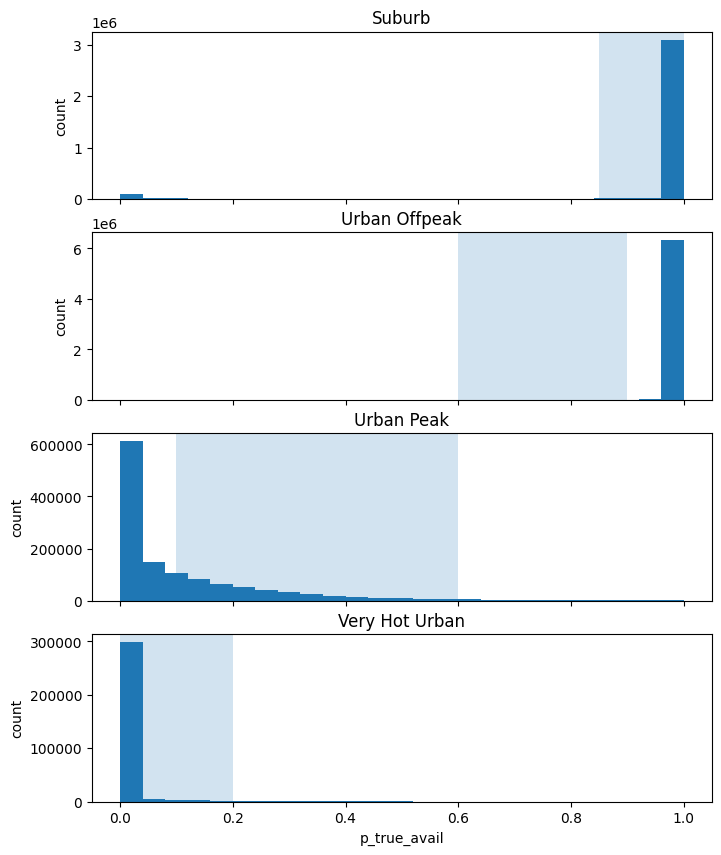

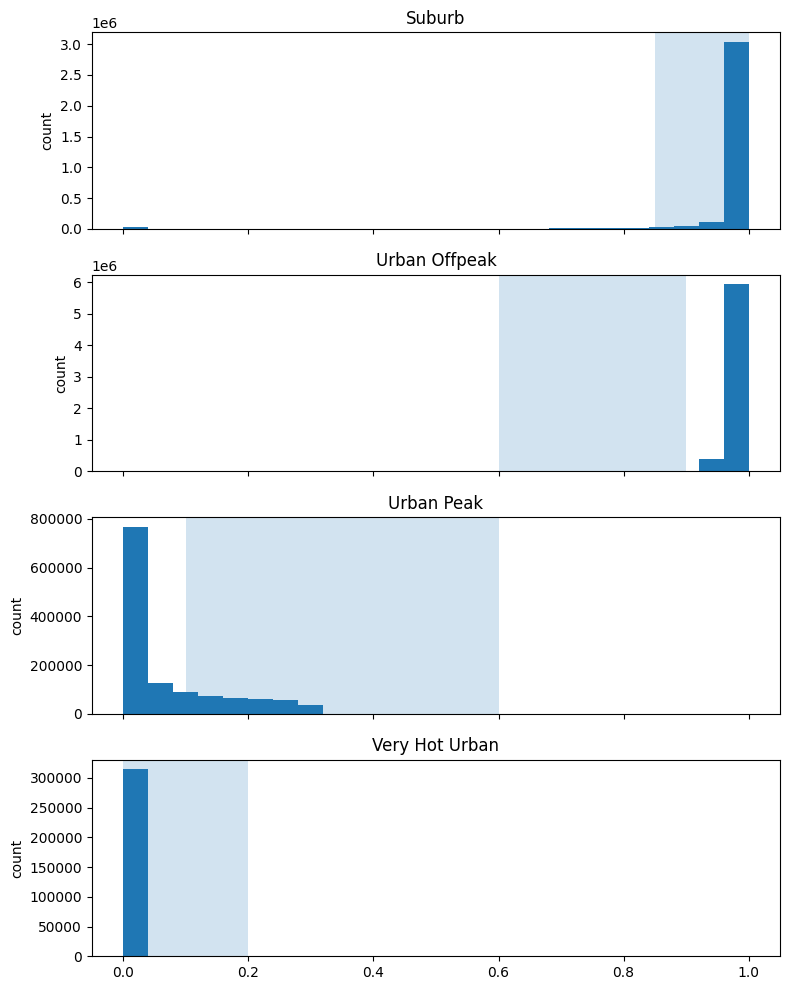

<Figure size 640x480 with 0 Axes>

In [9]:
def plot_hist_by_group(df):
    order = ["Suburb", "Urban Offpeak", "Urban Peak", "Very Hot Urban"]

    fig, axes = plt.subplots(len(order), 1, figsize=(8, 10), sharex=True)
    fig, axes2 = plt.subplots(len(order), 1, figsize=(8, 10), sharex=True)

    target_ranges = {
        "Suburb": (0.85, 1.00),
        "Urban Offpeak": (0.60, 0.90),
        "Urban Peak": (0.10, 0.60),
        "Very Hot Urban": (0.00, 0.20),
    }

    for ax, g in zip(axes, order):
        vals = df.loc[df["group"] == g, "p_true_avail"].dropna().values
        if len(vals) == 0:
            ax.set_title(f"{g} (no data)")
            continue

        ax.hist(vals, bins=25, range=(0, 1))
        lo, hi = target_ranges[g]
        ax.axvspan(lo, hi, alpha=0.2)
        ax.set_title(g)
        ax.set_ylabel("count")

    for ax, g in zip(axes2, order):
        vals = df.loc[df["group"] == g, "p_avail"].dropna().values
        if len(vals) == 0:
            ax.set_title(f"{g} (no data)")
            continue

        ax.hist(vals, bins=25, range=(0, 1))
        lo, hi = target_ranges[g]
        ax.axvspan(lo, hi, alpha=0.2)
        ax.set_title(g)
        ax.set_ylabel("count")

    axes[-1].set_xlabel("p_true_avail")
    plt.tight_layout()
    plt.show()

    axes2[-1].set_xlabel("p_avail")
    plt.tight_layout()
    plt.show()

plot_hist_by_group(df_check)

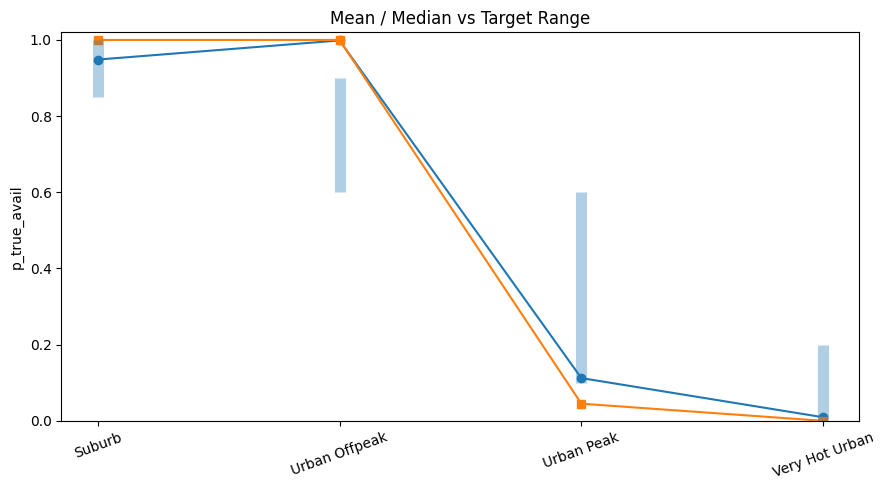

In [10]:
def plot_group_mean_vs_target(df):
    order = ["Suburb", "Urban Offpeak", "Urban Peak", "Very Hot Urban"]
    target_ranges = {
        "Suburb": (0.85, 1.00),
        "Urban Offpeak": (0.60, 0.90),
        "Urban Peak": (0.10, 0.60),
        "Very Hot Urban": (0.00, 0.20),
    }

    stats = []
    for g in order:
        vals = df.loc[df["group"] == g, "p_true_avail"].dropna()
        if len(vals) == 0:
            continue
        stats.append({
            "group": g,
            "mean": vals.mean(),
            "median": vals.median(),
            "q25": vals.quantile(0.25),
            "q75": vals.quantile(0.75),
        })

    stat_df = pd.DataFrame(stats)

    x = np.arange(len(stat_df))

    plt.figure(figsize=(9, 5))
    plt.plot(x, stat_df["mean"], marker="o")    # circle
    plt.plot(x, stat_df["median"], marker="s")  # square

    for i, g in enumerate(stat_df["group"]):
        lo, hi = target_ranges[g]
        plt.vlines(i, lo, hi, linewidth=8, alpha=0.35)

    plt.xticks(x, stat_df["group"], rotation=20)
    plt.ylim(0, 1.02)
    plt.ylabel("p_true_avail")
    plt.title("Mean / Median vs Target Range")
    plt.tight_layout()
    plt.show()

plot_group_mean_vs_target(df_check)

In [11]:
def summarize_target_hit_rate(df):
    target_ranges = {
        "Suburb": (0.85, 1.00),
        "Urban Offpeak": (0.60, 0.90),
        "Urban Peak": (0.10, 0.60),
        "Very Hot Urban": (0.00, 0.20),
    }

    rows = []
    for g, (lo, hi) in target_ranges.items():
        sub = df[df["group"] == g]["p_true_avail"].dropna()
        if len(sub) == 0:
            continue

        hit = ((sub >= lo) & (sub <= hi)).mean()
        rows.append({
            "group": g,
            "n": len(sub),
            "mean": sub.mean(),
            "median": sub.median(),
            "hit_rate_in_target_range": hit,
            "q25": sub.quantile(0.25),
            "q75": sub.quantile(0.75),
        })

    return pd.DataFrame(rows)

summary_df = summarize_target_hit_rate(df_check)
summary_df

,group,n,mean,median,hit_rate_in_target_range,q25,q75
0,Suburb,3360192,0.948454,1.000,0.934120,1.0,1.00
1,Urban Offpeak,6346714,0.998683,1.000,0.000241,1.0,1.00
2,Urban Peak,1271671,0.112233,0.045,0.332086,0.0,0.16
3,Very Hot Urban,315008,0.009405,0.000,0.986200,0.0,0.00


In [12]:
df_eval.groupby("is_city")[["p_avail","p_true_avail"]].mean()

,p_avail,p_true_avail
is_city,,
0,0.960897,0.948454
1,0.793950,0.813529


In [13]:
def eval_prob_metrics(df: pd.DataFrame):
    err = df["p_avail"].to_numpy() - df["p_true_avail"].to_numpy()
    brier = float(np.mean(err**2))
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    return {"brier": brier, "mae": mae, "rmse": rmse}

metrics = eval_prob_metrics(df_eval)
metrics

{'brier': 0.007853316213039876,
 'mae': 0.03963979662402432,
 'rmse': 0.08861893823015415}

In [14]:
def expected_calibration_error(df: pd.DataFrame, n_bins: int = 10):
    p = df["p_avail"].to_numpy()
    t = df["p_true_avail"].to_numpy()

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    # 每個點屬於哪個 bin
    idx = np.digitize(p, bins, right=True) - 1
    idx = np.clip(idx, 0, n_bins - 1)

    ece = 0.0
    for b in range(n_bins):
        mask = (idx == b)
        if not np.any(mask):
            continue
        w = np.mean(mask)
        ece += w * abs(np.mean(p[mask]) - np.mean(t[mask]))
    return float(ece)

ece = expected_calibration_error(df_eval, n_bins=10)
ece

0.020498199481456314

             bin  pred_mean  true_mean         n
0  (-0.001, 0.1]   0.013854   0.046869   1296905
1     (0.1, 0.2]   0.146762   0.213332    189593
2     (0.2, 0.3]   0.248919   0.288238    150477
3     (0.3, 0.4]   0.350208   0.356038    144117
4     (0.4, 0.5]   0.450786   0.426510    152072
5     (0.5, 0.6]   0.551611   0.502196    177120
6     (0.6, 0.7]   0.652537   0.589115    230495
7     (0.7, 0.8]   0.754316   0.698516    343744
8     (0.8, 0.9]   0.858580   0.839724    740474
9     (0.9, 1.0]   0.977990   0.993524  10513051


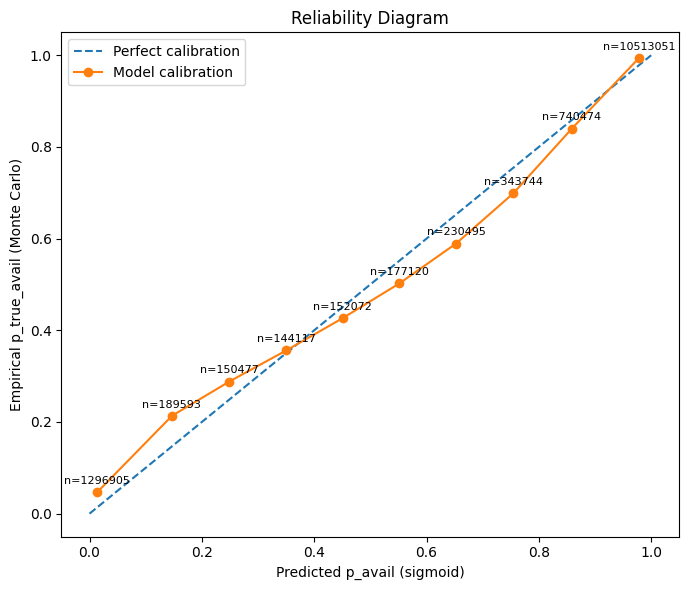

In [15]:
def plot_reliability(df: pd.DataFrame, n_bins: int = 10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    df2 = df.copy()
    df2["bin"] = pd.cut(df2["p_avail"], bins=bins, include_lowest=True)

    calib = (df2.groupby("bin", observed=True)
             .agg(pred_mean=("p_avail", "mean"),
                  true_mean=("p_true_avail", "mean"),
                  n=("p_avail", "size"))
             .reset_index())

    print(calib)

    plt.figure(figsize=(7,6))
    plt.plot([0,1],[0,1], linestyle="--", label="Perfect calibration")
    plt.plot(calib["pred_mean"], calib["true_mean"], marker="o", label="Model calibration")

    for _, row in calib.iterrows():
        plt.annotate(
            f'n={int(row["n"])}',
            (row["pred_mean"], row["true_mean"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8
        )

    plt.xlabel("Predicted p_avail (sigmoid)")
    plt.ylabel("Empirical p_true_avail (Monte Carlo)")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_reliability(df_eval)

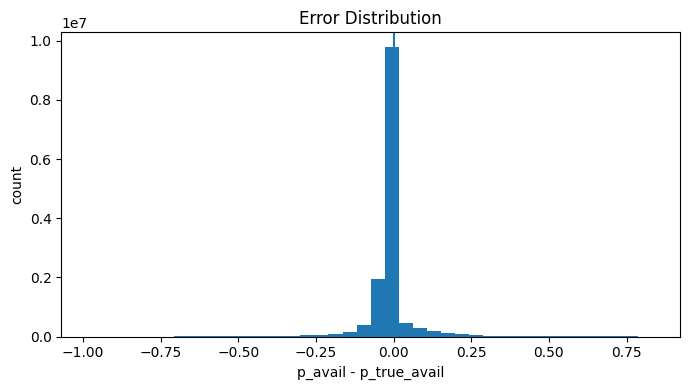

In [16]:
def plot_error_hist(df: pd.DataFrame):
    err = (df["p_avail"] - df["p_true_avail"]).to_numpy()
    plt.figure(figsize=(7,4))
    plt.hist(err, bins=40)
    plt.axvline(0.0)
    plt.xlabel("p_avail - p_true_avail")
    plt.ylabel("count")
    plt.title("Error Distribution")
    plt.tight_layout()
    plt.show()

plot_error_hist(df_eval)

In [17]:
"""
parking_calibrator.py

校準演算法：把 sigmoid 輸出的 p_avail 校準到接近 Monte Carlo p_true_avail。

三層策略（自動選最優）：
  1. ThetaRefitter     - 直接重新擬合 sigmoid 的 theta0, theta1（最可解釋）
  2. PlattCalibrator   - 對 logit(p_avail) 做線性回歸（Platt Scaling）
  3. IsotonicCalibrator - 保序回歸（最彈性，適合非線性偏差，但可解釋性幾乎沒有）

使用方式：
    cal = ParkingCalibrator()
    cal.fit(df_eval)                   # df_eval 需要 pressure, p_avail, p_true_avail
    df_out = cal.transform(df_prob)    # 新增 p_calibrated 欄位
    cal.report()                       # 印出校準前後指標對比
"""

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit, logit
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
import warnings

# ─────────────────────────────────────────────
# 共用工具
# ─────────────────────────────────────────────

def _sigmoid(z: np.ndarray) -> np.ndarray:
    return expit(z)

def _ece(p_pred: np.ndarray, p_true: np.ndarray, n_bins: int = 10) -> float:
    """Expected Calibration Error（越小越好）"""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx  = np.clip(np.digitize(p_pred, bins, right=True) - 1, 0, n_bins - 1)
    ece  = 0.0
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            continue
        ece += m.mean() * abs(p_pred[m].mean() - p_true[m].mean())
    return float(ece)

def _metrics(p_pred: np.ndarray, p_true: np.ndarray) -> dict:
    err = p_pred - p_true
    return {
        "mae":    float(np.mean(np.abs(err))),
        "rmse":   float(np.sqrt(np.mean(err**2))),
        "brier":  float(np.mean(err**2)),
        "ece":    _ece(p_pred, p_true),
        "bias":   float(np.mean(err)),          # 正=高估，負=低估
    }


# ─────────────────────────────────────────────
# 策略一：直接重新擬合 theta0, theta1
# ─────────────────────────────────────────────

class ThetaRefitter:
    """
    直接從 pressure → p_true_avail 重新擬合 sigmoid 參數。
    可選擇對 city / suburb 分別擬合（is_city_split=True）。

    p_avail = sigmoid(theta0 - theta1 * pressure)
    """

    def __init__(self, is_city_split: bool = True):
        self.is_city_split = is_city_split
        self.params_: dict = {}   # {"city": (t0, t1), "suburb": (t0, t1)} or {"all": (t0, t1)}

    def _fit_group(self, pressure: np.ndarray, y: np.ndarray,
                   init: tuple = (0.5, 10.0)) -> tuple:
        def mse(params):
            t0, t1 = params
            p = _sigmoid(t0 - t1 * pressure)
            return float(np.mean((p - y) ** 2))

        res = minimize(mse, x0=list(init), method="L-BFGS-B",
                       bounds=[(-10, 10), (0.1, 50)])
        return tuple(res.x)

    def fit(self, df: pd.DataFrame):
        """df 需要欄位：pressure, p_true_avail, is_city（分組用）"""
        pressure = df["pressure"].to_numpy(dtype=float)
        y        = df["p_true_avail"].to_numpy(dtype=float)

        if self.is_city_split and "is_city" in df.columns:
            for label, mask in [("city",   df["is_city"] == 1),
                                 ("suburb", df["is_city"] == 0)]:
                if mask.sum() < 10:
                    continue
                self.params_[label] = self._fit_group(pressure[mask], y[mask])
        else:
            self.params_["all"] = self._fit_group(pressure, y)

        return self

    def predict(self, df: pd.DataFrame) -> np.ndarray:
        pressure = df["pressure"].to_numpy(dtype=float)
        result   = np.empty(len(df), dtype=float)

        if "all" in self.params_:
            t0, t1 = self.params_["all"]
            result[:] = _sigmoid(t0 - t1 * pressure)
        else:
            for label, mask_fn in [("city",   df["is_city"] == 1),
                                    ("suburb", df["is_city"] == 0)]:
                mask = mask_fn.to_numpy()
                if not mask.any():
                    continue
                # fallback：若某組沒擬合，用另一組
                key = label if label in self.params_ else list(self.params_.keys())[0]
                t0, t1 = self.params_[key]
                result[mask] = _sigmoid(t0 - t1 * pressure[mask])

        return np.clip(result, 0.0, 1.0)


# ─────────────────────────────────────────────
# 策略二：Platt Scaling（logit 線性修正）
# ─────────────────────────────────────────────

class PlattCalibrator:
    """
    對 logit(p_avail) 做線性回歸：
        logit(p_calibrated) = a * logit(p_avail) + b

    等同於在既有 sigmoid 外再加一層仿射變換。
    同樣支援 city / suburb 分組。
    """

    def __init__(self, is_city_split: bool = True):
        self.is_city_split = is_city_split
        self.params_: dict = {}   # {"city": (a, b), "suburb": (a, b)}

    def _fit_group(self, p_avail: np.ndarray, y: np.ndarray) -> tuple:
        # 避免 logit(0) / logit(1) 的無限值
        p_clip = np.clip(p_avail, 1e-6, 1 - 1e-6)
        X = logit(p_clip).reshape(-1, 1)

        def mse(params):
            a, b = params
            p = _sigmoid(a * X[:, 0] + b)
            return float(np.mean((p - y) ** 2))

        res = minimize(mse, x0=[1.0, 0.0], method="L-BFGS-B",
                       bounds=[(0.1, 50), (-10, 10)])
        return tuple(res.x)

    def fit(self, df: pd.DataFrame):
        p_avail = df["p_avail"].to_numpy(dtype=float)
        y       = df["p_true_avail"].to_numpy(dtype=float)

        if self.is_city_split and "is_city" in df.columns:
            for label, mask in [("city",   df["is_city"] == 1),
                                 ("suburb", df["is_city"] == 0)]:
                if mask.sum() < 10:
                    continue
                self.params_[label] = self._fit_group(p_avail[mask.to_numpy()], y[mask.to_numpy()])
        else:
            self.params_["all"] = self._fit_group(p_avail, y)

        return self

    def predict(self, df: pd.DataFrame) -> np.ndarray:
        p_clip  = np.clip(df["p_avail"].to_numpy(dtype=float), 1e-6, 1 - 1e-6)
        log_p   = logit(p_clip)
        result  = np.empty(len(df), dtype=float)

        if "all" in self.params_:
            a, b = self.params_["all"]
            result[:] = _sigmoid(a * log_p + b)
        else:
            for label, mask_fn in [("city",   df["is_city"] == 1),
                                    ("suburb", df["is_city"] == 0)]:
                mask = mask_fn.to_numpy()
                if not mask.any():
                    continue
                key = label if label in self.params_ else list(self.params_.keys())[0]
                a, b = self.params_[key]
                result[mask] = _sigmoid(a * log_p[mask] + b)

        return np.clip(result, 0.0, 1.0)


# ─────────────────────────────────────────────
# 策略三：Isotonic Regression（非線性保序回歸）
# ─────────────────────────────────────────────

class IsotonicCalibrator:
    """
    保序回歸：對 p_avail 的排序保持單調，但允許任意非線性映射。
    適合 sigmoid 偏差形狀複雜的情況，但可解釋性最低。
    支援 city / suburb 分組。
    """

    def __init__(self, is_city_split: bool = True):
        self.is_city_split = is_city_split
        self.models_: dict = {}

    def fit(self, df: pd.DataFrame):
        p_avail = df["p_avail"].to_numpy(dtype=float)
        y       = df["p_true_avail"].to_numpy(dtype=float)

        if self.is_city_split and "is_city" in df.columns:
            for label, mask in [("city",   df["is_city"] == 1),
                                 ("suburb", df["is_city"] == 0)]:
                if mask.sum() < 10:
                    continue
                iso = IsotonicRegression(out_of_bounds="clip")
                iso.fit(p_avail[mask.to_numpy()], y[mask.to_numpy()])
                self.models_[label] = iso
        else:
            iso = IsotonicRegression(out_of_bounds="clip")
            iso.fit(p_avail, y)
            self.models_["all"] = iso

        return self

    def predict(self, df: pd.DataFrame) -> np.ndarray:
        p_avail = df["p_avail"].to_numpy(dtype=float)
        result  = np.empty(len(df), dtype=float)

        if "all" in self.models_:
            result[:] = self.models_["all"].predict(p_avail)
        else:
            for label, mask_fn in [("city",   df["is_city"] == 1),
                                    ("suburb", df["is_city"] == 0)]:
                mask = mask_fn.to_numpy()
                if not mask.any():
                    continue
                key = label if label in self.models_ else list(self.models_.keys())[0]
                result[mask] = self.models_[key].predict(p_avail[mask])

        return np.clip(result, 0.0, 1.0)


# ─────────────────────────────────────────────
# 主類別：自動選最優策略
# ─────────────────────────────────────────────

class ParkingCalibrator:
    """
    自動校準器：用驗證集選出 ECE 最低的策略。

    用法：
        cal = ParkingCalibrator()
        cal.fit(df_eval)
        df_prob["p_calibrated"] = cal.transform(df_prob)
        cal.report()
    """

    STRATEGIES = {
        "ThetaRefit":  ThetaRefitter,
        "Platt":       PlattCalibrator,
    }
    #  "Isotonic":    IsotonicCalibrator
    
    def __init__(self, is_city_split: bool = True, val_frac: float = 0.2,
                 random_state: int = 42):
        self.is_city_split  = is_city_split
        self.val_frac       = val_frac
        self.random_state   = random_state
        self.best_name_: str | None    = None
        self.best_model_               = None
        self.metrics_before_: dict     = {}
        self.metrics_after_:  dict     = {}
        self.all_metrics_:    dict     = {}

    def fit(self, df_eval: pd.DataFrame):
        """
        df_eval 需要欄位：pressure, p_avail, p_true_avail
        is_city 為可選（有才分組）
        """
        required = {"pressure", "p_avail", "p_true_avail"}
        missing  = required - set(df_eval.columns)
        if missing:
            raise ValueError(f"df_eval 缺少欄位: {missing}")

        # Train / val split（依 park_id 分，避免同一停車場同時出現在兩組）
        rng = np.random.default_rng(self.random_state)
        if "park_id" in df_eval.columns:
            park_ids   = df_eval["park_id"].unique()
            n_val      = max(1, int(len(park_ids) * self.val_frac))
            val_parks  = rng.choice(park_ids, size=n_val, replace=False)
            val_mask   = df_eval["park_id"].isin(val_parks)
        else:
            val_mask = pd.Series(
                rng.random(len(df_eval)) < self.val_frac, index=df_eval.index)

        df_train = df_eval[~val_mask].copy()
        df_val   = df_eval[val_mask].copy()

        # 校準前基準
        self.metrics_before_ = _metrics(
            df_val["p_avail"].to_numpy(), df_val["p_true_avail"].to_numpy())

        # 逐一擬合，選 val ECE 最低
        best_ece   = np.inf
        best_name  = None
        best_model = None

        for name, Cls in self.STRATEGIES.items():
            try:
                model = Cls(is_city_split=self.is_city_split)
                model.fit(df_train)
                p_cal = model.predict(df_val)
                m = _metrics(p_cal, df_val["p_true_avail"].to_numpy())
                self.all_metrics_[name] = m
                print(f"  [{name:15s}]  ECE={m['ece']:.4f}  MAE={m['mae']:.4f}  "
                      f"Bias={m['bias']:+.4f}")
                if m["ece"] < best_ece:
                    best_ece   = m["ece"]
                    best_name  = name
                    best_model = model
            except Exception as e:
                warnings.warn(f"{name} 擬合失敗：{e}")

        # 用全資料重新 fit 最優策略
        self.best_name_  = best_name
        self.best_model_ = self.STRATEGIES[best_name](
            is_city_split=self.is_city_split)
        self.best_model_.fit(df_eval)

        # 最終指標（in-sample，僅供參考）
        p_final = self.best_model_.predict(df_eval)
        self.metrics_after_ = _metrics(
            p_final, df_eval["p_true_avail"].to_numpy())

        print(f"\n✅ 選用策略：{self.best_name_}（val ECE={best_ece:.4f}）")
        return self

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """回傳 np.ndarray，長度與 df 相同"""
        if self.best_model_ is None:
            raise RuntimeError("請先呼叫 fit()")
        return self.best_model_.predict(df)

    def apply(self, df: pd.DataFrame, col: str = "p_calibrated") -> pd.DataFrame:
        """在 df 上新增 p_calibrated 欄位並回傳"""
        out = df.copy()
        out[col] = self.transform(df)
        return out

    def report(self):
        """印出校準前後指標對比"""
        print("=" * 55)
        print(f"  ParkingCalibrator  策略 = {self.best_name_}")
        print("=" * 55)
        header = f"{'Metric':>8}  {'Before':>10}  {'After':>10}  {'Δ':>10}"
        print(header)
        print("-" * 55)
        for key in ["mae", "rmse", "brier", "ece", "bias"]:
            before = self.metrics_before_.get(key, float("nan"))
            after  = self.metrics_after_.get(key, float("nan"))
            delta  = after - before
            flag   = "✅" if delta < 0 else ("➡" if abs(delta) < 1e-4 else "⚠️")
            print(f"  {key:>6}  {before:>10.4f}  {after:>10.4f}  "
                  f"{delta:>+10.4f} {flag}")
        print("=" * 55)

    def plot_reliability(self, df_eval: pd.DataFrame, n_bins: int = 10):
        """畫校準前後的 Reliability Diagram"""
        try:
            import matplotlib.pyplot as plt
        except ImportError:
            print("需要 matplotlib")
            return

        p_before = df_eval["p_avail"].to_numpy(dtype=float)
        p_after  = self.transform(df_eval)
        p_true   = df_eval["p_true_avail"].to_numpy(dtype=float)

        bins = np.linspace(0, 1, n_bins + 1)

        def _bin_stats(p_pred):
            idx = np.clip(np.digitize(p_pred, bins, right=True) - 1, 0, n_bins - 1)
            xs, ys = [], []
            for b in range(n_bins):
                m = idx == b
                if m.any():
                    xs.append(p_pred[m].mean())
                    ys.append(p_true[m].mean())
            return np.array(xs), np.array(ys)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, p_pred, title in [
            (axes[0], p_before, "Before Calibration (sigmoid)"),
            (axes[1], p_after,  f"After Calibration ({self.best_name_})"),
        ]:
            xs, ys = _bin_stats(p_pred)
            ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
            ax.plot(xs, ys, "o-", label="Model")
            ece_val = _ece(p_pred, p_true)
            ax.set_title(f"{title}\nECE={ece_val:.4f}")
            ax.set_xlabel("Predicted p_avail")
            ax.set_ylabel("Empirical p_true_avail")
            ax.legend()
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)

        plt.tight_layout()
        plt.savefig("calibration_reliability.png", dpi=120)
        plt.show()

In [18]:
cal = ParkingCalibrator()
cal.fit(df_eval)                   # df_eval 需要 pressure, p_avail, p_true_avail
df_out = cal.transform(df_prob)    # 新增 p_calibrated 欄位
cal.report() 

  [ThetaRefit     ]  ECE=0.1085  MAE=0.1251  Bias=-0.0411
  [Platt          ]  ECE=0.0183  MAE=0.0357  Bias=-0.0137

✅ 選用策略：Platt（val ECE=0.0183）
  ParkingCalibrator  策略 = Platt
  Metric      Before       After           Δ
-------------------------------------------------------
     mae      0.0401      0.0350     -0.0051 ✅
    rmse      0.0886      0.0762     -0.0124 ✅
   brier      0.0078      0.0058     -0.0020 ✅
     ece      0.0203      0.0180     -0.0022 ✅
    bias     -0.0133     -0.0124     +0.0009 ⚠️


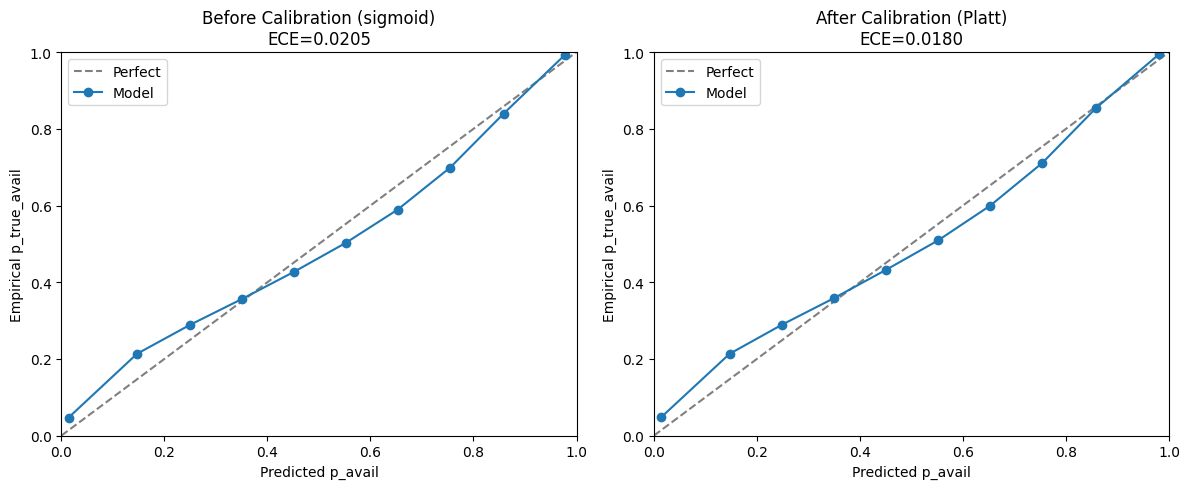

In [19]:
cal.plot_reliability(df_eval)

a = 1.0006,  b = -0.0465
  a > 1 → sigmoid 更陡（高機率更高，低機率更低）
  a < 1 → sigmoid 更平（向 0.5 收縮）
  b > 0 → 整體往高機率平移（系統性低估時用）
  b < 0 → 整體往低機率平移（系統性高估時用）
a = 1.0043,  b = 0.0987
  a > 1 → sigmoid 更陡（高機率更高，低機率更低）
  a < 1 → sigmoid 更平（向 0.5 收縮）
  b > 0 → 整體往高機率平移（系統性低估時用）
  b < 0 → 整體往低機率平移（系統性高估時用）

a = 2.0601,  b = -3.9377
  a > 1 → sigmoid 更陡（高機率更高，低機率更低）
  a < 1 → sigmoid 更平（向 0.5 收縮）
  b > 0 → 整體往高機率平移（系統性低估時用）
  b < 0 → 整體往低機率平移（系統性高估時用）



C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 26657 (\N{CJK UNIFIED IDEOGRAPH-6821}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_25244\3919925971.py:67: UserWarning: Glyph 24460 (\N{CJK 

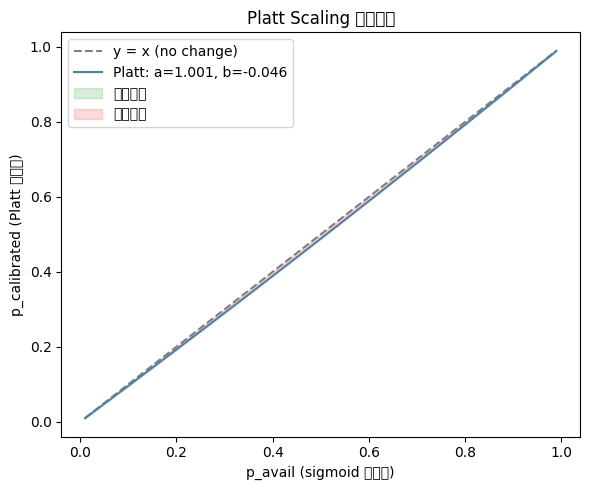

p_avail               MAE=0.0396  Bias=-0.0119
p_platt               MAE=0.0401  Bias=-0.0139
p_platt_split         MAE=0.0350  Bias=-0.0124


In [20]:
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def fit_platt_scaling(
    p_avail: np.ndarray,        # sigmoid 原始輸出
    p_true: np.ndarray,         # Monte Carlo 真實機率（目標）
    init_a: float = 1.0,        # a 初始值（1=不縮放）
    init_b: float = 0.0,        # b 初始值（0=不偏移）
) -> tuple[float, float]:
    """
    最小化 MSE:  min_{a,b} mean( (sigmoid(a*logit(p) + b) - p_true)^2 )
    回傳 (a, b)
    """
    # 避免 logit(0) / logit(1) 的 inf
    p_clip = np.clip(p_avail, 1e-6, 1 - 1e-6)
    log_odds = logit(p_clip)   # shape: (n,)

    def loss(params):
        a, b = params
        p_cal = expit(a * log_odds + b)          # sigmoid(a * logit(p) + b)
        return float(np.mean((p_cal - p_true) ** 2))

    # L-BFGS-B 有界優化
    res = minimize(
        loss,
        x0=[init_a, init_b],
        method="L-BFGS-B",
        bounds=[(0.1, 50.0), (-20.0, 20.0)],      # a > 0 確保單調性
        options={"ftol": 1e-9, "gtol": 1e-7, "maxiter": 500}
    )

    a_opt, b_opt = res.x
    print(f"a = {a_opt:.4f},  b = {b_opt:.4f}")
    print(f"  a > 1 → sigmoid 更陡（高機率更高，低機率更低）")
    print(f"  a < 1 → sigmoid 更平（向 0.5 收縮）")
    print(f"  b > 0 → 整體往高機率平移（系統性低估時用）")
    print(f"  b < 0 → 整體往低機率平移（系統性高估時用）")

    return a_opt, b_opt


def apply_platt(p_avail: np.ndarray, a: float, b: float) -> np.ndarray:
    p_clip   = np.clip(p_avail, 1e-6, 1 - 1e-6)
    log_odds = logit(p_clip)
    return np.clip(expit(a * log_odds + b), 0.0, 1.0)


def plot_platt_curve(a: float, b: float):
    """畫出 p_avail → p_calibrated 的映射曲線"""
    p_in  = np.linspace(0.01, 0.99, 200)
    p_out = apply_platt(p_in, a, b)

    plt.figure(figsize=(6, 5))
    plt.plot(p_in, p_in, "--", color="gray", label="y = x (no change)")
    plt.plot(p_in, p_out, color="steelblue", label=f"Platt: a={a:.3f}, b={b:.3f}")
    plt.fill_between(p_in, p_in, p_out,
                     where=(p_out > p_in), alpha=0.15, color="green", label="往上修正")
    plt.fill_between(p_in, p_in, p_out,
                     where=(p_out < p_in), alpha=0.15, color="red",   label="往下修正")
    plt.xlabel("p_avail (sigmoid 原始值)")
    plt.ylabel("p_calibrated (Platt 校準後)")
    plt.title("Platt Scaling 映射曲線")
    plt.legend()
    plt.tight_layout()
    plt.show()


# df_eval 需有 p_avail, p_true_avail, is_city
p_avail = df_eval["p_avail"].to_numpy()
p_true  = df_eval["p_true_avail"].to_numpy()

# 全體擬合
a, b = fit_platt_scaling(p_avail, p_true)
df_eval["p_platt"] = apply_platt(p_avail, a, b)

# 市區 / 郊區分別擬合（通常效果更好）
for label, mask in [("city", df_eval["is_city"]==1), ("suburb", df_eval["is_city"]==0)]:
    a_g, b_g = fit_platt_scaling(p_avail[mask], p_true[mask])
    df_eval.loc[mask, "p_platt_split"] = apply_platt(p_avail[mask], a_g, b_g)
    print()

# 畫映射曲線
plot_platt_curve(a, b)

# 校準前後比較
for col in ["p_avail", "p_platt", "p_platt_split"]:
    err = df_eval[col] - df_eval["p_true_avail"]
    print(f"{col:20s}  MAE={np.abs(err).mean():.4f}  Bias={err.mean():+.4f}")